## Module 3: Phân tích Rủi ro Hủy hợp đồng (Lapse Risk Analysis)

Trong hai module trước, ta giả định khách hàng sẽ giữ hợp đồng cho đến khi tử vong. Tuy nhiên, trong thực tế, khách hàng có thể ngừng đóng phí (Lapse). 

**Giả định mới:**
*   **Lapse Rate (Tỷ lệ hủy hợp đồng):** Giả định là 5%/năm. Nghĩa là mỗi năm có 5% số người đang sống quyết định hủy hợp đồng.
*   Khi khách hàng hủy hợp đồng, công ty sẽ không thu được phí của các năm sau, nhưng đồng thời cũng không phải chi trả quyền lợi tử vong cho người đó nữa.

Chúng ta sẽ tính lại số người thực sự còn duy trì hợp đồng (Active Policies) qua từng năm.

In [1]:
import pandas as pd

# 1. Gọi lại dữ liệu tử vong từ file CSV
mortality = pd.read_csv("../data/mortality_table.csv")
df_lapse = mortality[['age', 'qx']].copy()

# 2. Thiết lập tỷ lệ hủy hợp đồng (Lapse Rate) cố định là 5%
lapse_rate = 0.05
df_lapse['lapse_rate'] = lapse_rate

# 3. Tính Xác suất Hợp đồng CÒN HIỆU LỰC trong năm đó
# Khách hàng phải thỏa mãn 2 điều kiện: Không chết (1 - qx) VÀ Không hủy hợp đồng (1 - lapse_rate)
df_lapse['prob_stay_active'] = (1 - df_lapse['qx']) * (1 - df_lapse['lapse_rate'])

# 4. Tính Xác suất Tích lũy (Xác suất 1 khách hàng giữ hợp đồng từ năm 30 tuổi đến hiện tại)
df_lapse['cumulative_active'] = df_lapse['prob_stay_active'].cumprod()

# In ra 5 dòng đầu để kiểm tra
df_lapse.head()

,age,qx,lapse_rate,prob_stay_active,cumulative_active
0,30,0.00095,0.05,0.949097,0.949097
1,31,0.00100,0.05,0.949050,0.900741
2,32,0.00105,0.05,0.949002,0.854805
3,33,0.00110,0.05,0.948955,0.811172
4,34,0.00115,0.05,0.948908,0.769727


### Tính toán lại Dòng tiền với Rủi ro Hủy hợp đồng (Lapse-Adjusted Cash Flow)

Khi tích hợp Lapse Rate, số lượng hợp đồng còn hiệu lực (Active Policies) sẽ giảm nhanh hơn so với việc chỉ xét tỷ lệ tử vong. Điều này ảnh hưởng trực tiếp đến dòng tiền:

1. **Dòng tiền thu mới:**
   $$\text{Lapse-Adjusted Premium} = \text{Annual Premium} \times \text{Cumulative Active}$$

2. **Dòng tiền chi mới:**
   Khách hàng chỉ được bồi thường nếu họ giữ hợp đồng đến năm hiện tại và tử vong trong năm đó.
   $$\text{Lapse-Adjusted Benefit} = \text{Sum Assured} \times (\text{Cumulative Active} \times q_x)$$

In [2]:
# Thiết lập các giả định 
sum_assured = 1000000000
annual_premium = 15000000
interest_rate = 0.05
v = 1 / (1 + interest_rate)

# Khởi tạo cột thời gian t
df_lapse['t'] = df_lapse['age'] - df_lapse['age'].min()

# 1. Tính toán Hiện giá Dòng tiền Thu (Có Lapse)
df_lapse['lapse_premium_inflow'] = annual_premium * df_lapse['cumulative_active']
df_lapse['lapse_pv_premium'] = df_lapse['lapse_premium_inflow'] * (v ** df_lapse['t'])

# 2. Tính toán Hiện giá Dòng tiền Chi (Có Lapse)
df_lapse['lapse_death_outflow'] = sum_assured * (df_lapse['cumulative_active'] * df_lapse['qx'])
df_lapse['lapse_pv_death'] = df_lapse['lapse_death_outflow'] * (v ** (df_lapse['t'] + 1))

# 3. Tính Lợi nhuận mới
total_lapse_premium = df_lapse['lapse_pv_premium'].sum()
total_lapse_death = df_lapse['lapse_pv_death'].sum()
lapse_profit = total_lapse_premium - total_lapse_death
lapse_profit_margin = lapse_profit / total_lapse_premium

pd.set_option('display.float_format', lambda x: '%.0f' % x)

# In kết quả
print(f"Tổng PV Thu: {total_lapse_premium:,.0f} VNĐ")
print(f"Tổng PV Chi: {total_lapse_death:,.0f} VNĐ")
print(f"Lợi nhuận kỳ vọng: {lapse_profit:,.0f} VNĐ")
print(f"Biên lợi nhuận mới: {lapse_profit_margin * 100:.2f}%\n")

# In 5 dòng đầu của bảng dữ liệu mới
df_lapse[['age', 'lapse_premium_inflow', 'lapse_death_outflow']].head()

Tổng PV Thu: 130,004,500 VNĐ
Tổng PV Chi: 12,560,924 VNĐ
Lợi nhuận kỳ vọng: 117,443,576 VNĐ
Biên lợi nhuận mới: 90.34%



,age,lapse_premium_inflow,lapse_death_outflow
0,30,14236462,901643
1,31,13511115,900741
2,32,12822082,897546
3,33,12167579,892289
4,34,11545906,885186


### Nhận xét Tác động của Lapse Risk

Khi so sánh với mô hình không có Lapse ở Module 2, ta rút ra các kết luận quan trọng sau:

1. **Giảm Lợi nhuận tuyệt đối (Absolute Profit Drop):** Do mất đi nguồn thu phí từ những khách hàng rời bỏ hợp đồng, tổng lợi nhuận kỳ vọng giảm mạnh.
2. **Tăng Biên lợi nhuận (Profit Margin Improvement):** Mặc dù thu ít tiền hơn, nhưng tỷ lệ sinh lời lại tăng lên. Nguyên nhân là do khách hàng thường hủy hợp đồng ở những năm đầu (khi rủi ro tử vong thấp). Việc này giúp công ty giải phóng được một lượng lớn Trách nhiệm bồi thường (Liability) ở những năm cuối hợp đồng khi rủi ro $q_x$ tăng cao.

Dưới đây là biểu đồ trực quan hóa Dòng tiền sau khi đã điều chỉnh rủi ro hủy hợp đồng (Lapse-Adjusted).

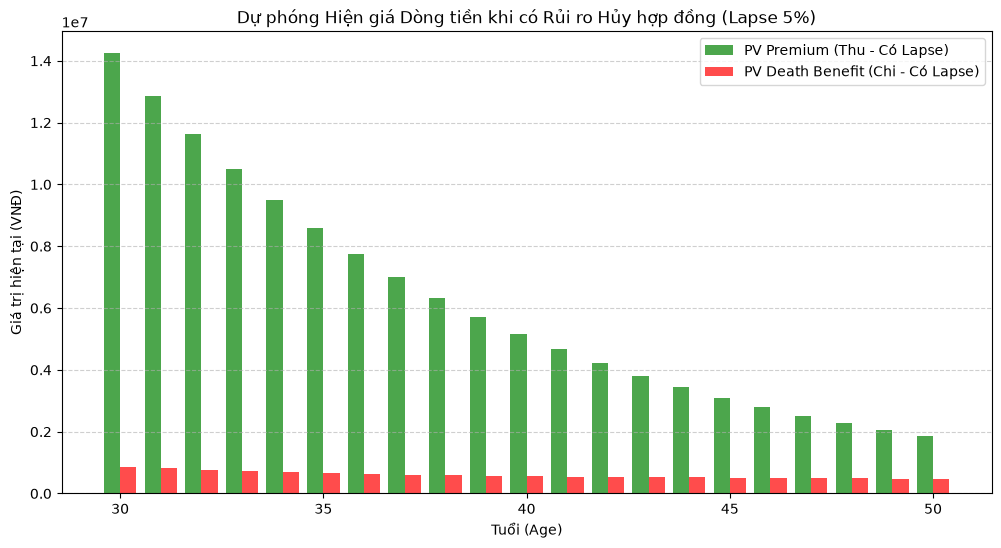

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ
plt.bar(df_lapse['age'] - 0.2, df_lapse['lapse_pv_premium'], width=0.4, label='PV Premium (Thu - Có Lapse)', color='green', alpha=0.7)
plt.bar(df_lapse['age'] + 0.2, df_lapse['lapse_pv_death'], width=0.4, label='PV Death Benefit (Chi - Có Lapse)', color='red', alpha=0.7)

plt.title('Dự phóng Hiện giá Dòng tiền khi có Rủi ro Hủy hợp đồng (Lapse 5%)')
plt.xlabel('Tuổi (Age)')
plt.ylabel('Giá trị hiện tại (VNĐ)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Lưu ảnh vào thư mục outputs
plt.savefig('../outputs/lapse_cashflow.png')

plt.show()

### Phân tích Trực quan hóa: Tác động của Lapse Risk

Nhìn vào biểu đồ, ta thấy rõ sự thay đổi của hình dáng dòng tiền khi áp dụng giả định Hủy hợp đồng (Lapse Rate = 5%):

*   **Dòng tiền thu sụt giảm mạnh (Cột màu xanh):** Dòng tiền phí bảo hiểm giảm dốc hơn rất nhiều so với mô hình không có Lapse. Nguyên nhân là do tệp khách hàng bị thu hẹp bởi tác động kép: Tỷ lệ tử vong ($q_x$) và Tỷ lệ hủy hợp đồng (5% mỗi năm). 
*   **Dòng tiền chi đi ngang và giảm dần (Cột màu đỏ):** Khác với Module 2 (cột đỏ tăng dần do rủi ro $q_x$ tăng theo tuổi), ở mô hình này, cột đỏ lại giữ ở mức thấp. Lý do là vì lượng khách hàng rời bỏ hệ thống quá nhanh, dẫn đến số người "trụ lại" đến những năm cuối để nhận bồi thường tử vong là rất thấp. Lợi ích từ việc giảm bồi thường này bù trừ một phần cho sự sụt giảm doanh thu.
*   **Kết luận:** Rủi ro hủy hợp đồng sớm làm giảm quy mô lợi nhuận tuyệt đối của công ty, nhưng lại vô tình đóng vai trò kiểm soát rủi ro đền bù ở giai đoạn sau của hợp đồng.